## **Texas Petroleum and Seismicity**

**Author:** Aliana Chen\
**Last Updated:** June 8, 2026

With the nation's largest petroleum industry, Texas has long been synonymous with oil. However, petroleum isn't just *shaping* the state's economy, it might also be *shaking* the ground beneath. Over the past few decades, Texas has seen a dramatic rise in seismic activity, and research claims that certain steps in the oil extraction process may be responsible.

So, in this analysis, we'll use **exploratory data analysis (EDA)**, **hypothesis testing**, and **regression** to investigate whether there really is a relationship between Texas petroleum production and earthquake activity.

The datasets used in this analysis can be found from [US Energy Information Administration](https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=pet&s=mcrfptx2&f=a) and [USGS Earthquakes](https://earthquake.usgs.gov/earthquakes/map/?extent=20.01465,-121.33301&extent=41.70573,-79.14551&range=search&timeZone=utc&search=%7B%22name%22:%22Search%20Results%22,%22params%22:%7B%22starttime%22:%221800-01-01%2000:00:00%22,%22endtime%22:%222026-05-21%2023:59:59%22,%22maxlatitude%22:37.132,%22minlatitude%22:25.483,%22maxlongitude%22:-93.162,%22minlongitude%22:-107.316,%22minmagnitude%22:2.5,%22orderby%22:%22time%22%7D%7D).

### **Table of Contents**
**I. [Loading Libraries and Data](#i-loading-libraries-and-data)**

**II. [Understanding the Data](#ii-understanding-the-data)**

**III. [Data Cleaning](#iii-data-cleaning)**

**IV. [Exploratory Data Analysis (EDA)](#iv-exploratory-data-analysis-eda)**

**V. [Chi-Square Test](#v-chi-square-test-of-independence)**

**VI. [Linear Regression](#vi-linear-regression)**

**VII. [The Gutenberg-Richter Law](#vii-the-gutenberg-richter-law)**

**VIII. [Conclusion](#viii-conclusion)**

### **I. Loading Libraries and Data**

Here, we'll load the libraries necessary for analysis, as well as our datasets.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from scipy.stats import linregress
from scipy.stats import zscore

In [2]:
quake = pd.read_csv('tx_eq_25.csv')
quake = quake[quake['place'].str.contains('TX|Texas', case=False, na=False)]

oil = pd.read_excel('mcrfptx2a.xlsx', sheet_name='Sheet1')

Our earthquake dataset actually contains data from outside Texas, so we've filtered the data to only include earthquakes inside Texas.

### **II. Understanding the Data**

In [3]:
quake.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-05-21T00:00:32.987Z,31.522,-104.007,4.6211,2.7,ml,44.0,62.0,0.0,0.3,...,2026-05-21T00:12:22.040Z,"30 km NW of Toyah, Texas",earthquake,0.000000,0.868437,0.2,34.0,automatic,tx,tx
3,2026-05-19T10:55:00.947Z,31.845,-101.813,9.4482,3.2,ml,53.0,42.0,0.1,0.2,...,2026-05-19T17:55:46.529Z,"30 km SE of Midland, Texas",earthquake,0.535593,0.747869,0.2,22.0,reviewed,tx,tx
6,2026-05-17T10:18:14.190Z,28.791,-98.984,7.0814,2.6,ml,30.0,77.0,0.1,0.3,...,2026-05-18T23:45:00.482Z,"15 km SE of Pearsall, Texas",earthquake,2.546033,0.871015,0.1,19.0,reviewed,tx,tx
10,2026-05-10T20:38:14.641Z,32.448,-102.054,6.7871,2.7,ml,45.0,54.0,0.1,0.0,...,2026-05-11T11:45:54.227Z,"32 km SSW of Los Ybanez, Texas",earthquake,0.358911,0.738057,0.2,42.0,reviewed,tx,tx
15,2026-05-04T23:12:08.328Z,31.168,-103.003,5.5872,3.1,ml,22.0,76.0,0.0,0.2,...,2026-05-14T00:06:37.040Z,"10 km SE of Coyanosa, Texas",earthquake,1.027253,1.364454,0.2,25.0,reviewed,tx,tx


In [4]:
quake.tail()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
15279,1932-04-09T10:17:00.000Z,31.700,-96.400,NaN,3.9,fa,NaN,NaN,NaN,NaN,...,2018-06-04T20:43:44.000Z,"8 km ENE of Mexia, Texas",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,sc
15280,1931-08-16T11:40:22.300Z,30.502,-104.575,1.0,5.8,lg,NaN,NaN,NaN,NaN,...,2024-02-05T00:43:32.336Z,"The 1931 Valentine, Texas Earthquake",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,ntt
15283,1925-07-30T12:17:00.000Z,35.400,-101.300,NaN,4.9,fa,NaN,NaN,NaN,NaN,...,2018-06-04T20:43:44.000Z,"9 km NE of Panhandle, Texas",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,sc
15285,1917-03-28T19:56:00.000Z,35.400,-101.300,NaN,3.8,fa,NaN,NaN,NaN,NaN,...,2018-06-04T20:43:44.000Z,"9 km NE of Panhandle, Texas",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,sc
15294,1891-01-08T06:00:00.000Z,31.700,-95.200,NaN,3.8,mfa,NaN,NaN,NaN,NaN,...,2021-03-31T08:34:19.667Z,"Near Rusk, Texas",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,bar


Earthquake data is recorded from 1891 to 2026.

We see that there are 22 different attributes recorded for each earthquake. However, for this analysis, we only care about the **year** and **magnitude**, so we'll be cleaning the dataset accordingly in the next section.

In [5]:
oil.head()

,Date,Texas Field Production of Crude Oil (Thousand Barrels per Day)
0,1981-06-30,2554
1,1982-06-30,2488
2,1983-06-30,2419
3,1984-06-30,2413
4,1985-06-30,2381


In [6]:
oil.tail()

,Date,Texas Field Production of Crude Oil (Thousand Barrels per Day)
40,2021-06-30,4785
41,2022-06-30,5125
42,2023-06-30,5485
43,2024-06-30,5675
44,2025-06-30,5751


Oil production data is recorded from 1981 to 2025.

This dataset is simpler: it gives the average production of crude oil per day for each year. Thus, only a little bit of cleaning is necessary to obtain **year** and **oil production**, which we'll do in the next section.

### **III. Data Cleaning**

Let's start by cleaning our earthquake dataset.

As mentioned before, the data useful to us is the year and magnitude. So, for each earthquake, we'll extract the year from the `time` column. We'll also clean this dataset so that the only columns displayed are `year` and `mag`.

In [7]:
quake = quake[['time', 'mag']]

quake['time'] = pd.to_datetime(quake['time'], errors='coerce', utc=True)
quake['year'] = quake['time'].dt.year

quake = quake[['year', 'mag']]

print(quake.columns)
print(quake.head())
print(quake.shape)

Index(['year', 'mag'], dtype='object')
    year  mag
0   2026  2.7
3   2026  3.2
6   2026  2.6
10  2026  2.7
15  2026  3.1
(2825, 2)


Next, we'll clean our oil production dataset.

Again, we'll extract the year from the `Date` column, so we end up with two columns: `year` and `oil_production`.

In [8]:
oil = pd.read_excel('mcrfptx2a.xlsx', sheet_name='Sheet1')

oil['oil_production'] = oil['Texas Field Production of Crude Oil (Thousand Barrels per Day)']

oil['Date'] = pd.to_datetime(oil['Date'], errors='coerce', utc=True)
oil['year'] = oil['Date'].dt.year

oil = oil[['year', 'oil_production']]

print(oil.columns)
print(oil.head())
print(oil.shape)

Index(['year', 'oil_production'], dtype='object')
   year  oil_production
0  1981            2554
1  1982            2488
2  1983            2419
3  1984            2413
4  1985            2381
(45, 2)


### **IV. Exploratory Data Analysis (EDA)**

To start, let's take a look at two significant dates in the Texas petroleum industry:
* **1901:** an oil-rich field named *Spindletop* was first discovered and exploited, marking the birth of the Texas petroleum industry.
* **1998:** the *Barnett Shale* in North Texas was the first commercially profitable well to use a revolutionary “slick water” hydraulic fracturing technique.

However, we only have oil production data going until 1981. So, to see if there’s a significant relationship between time period and earthquakes in Texas, we'll organize our data into these three time periods:
* **Pre-1901:** period before the petroleum industry’s big boom
* **1901-1997:** period using older fracking techniques
* **1998-present:** period using modern, commercial fracking techniques

In [9]:
def classify_period(year):
    if year < 1901:
        return "Pre-1901"
    elif year < 1998:
        return "1901-1997"
    else:
        return "1998-Present"

quake['period'] = quake['year'].apply(classify_period)

print(quake['period'].value_counts())

period
1998-Present    2753
1901-1997         71
Pre-1901           1
Name: count, dtype: int64


We can start by visualizing and analyzing some basic characteristics of earthquakes within each time period.

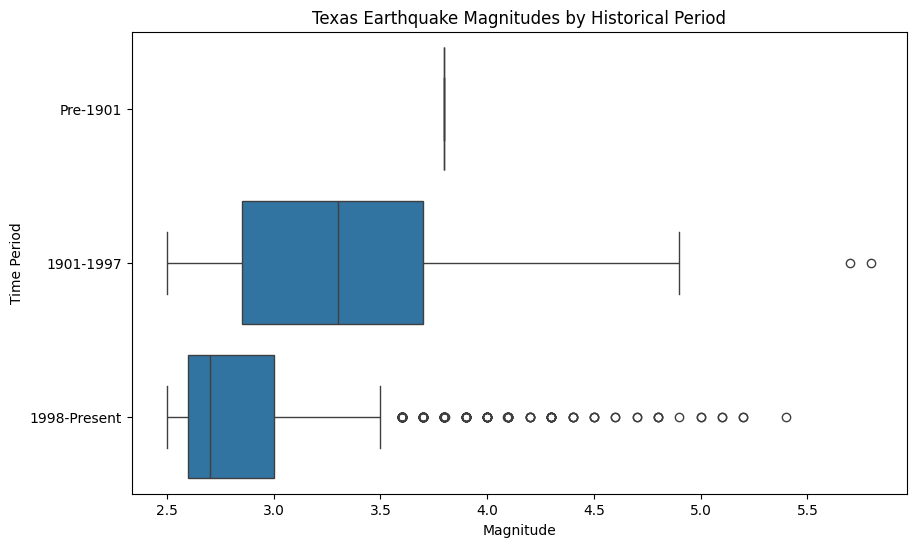

In [10]:
plt.figure(figsize=(10,6))

ax = sns.boxplot(data=quake, x='mag', y='period', orient='h')
ax.invert_yaxis()

plt.title("Texas Earthquake Magnitudes by Historical Period")
plt.xlabel("Magnitude")
plt.ylabel("Time Period")

plt.show()

In [11]:
summary = quake.groupby('period').agg({
    'mag': ['count', 'mean', 'max', 'std'],
})

my_order = ['Pre-1901', '1901-1997', '1998-Present']
summary = summary.reindex(my_order)

print(summary)

               mag                         
             count      mean  max       std
period                                     
Pre-1901         1  3.800000  3.8       NaN
1901-1997       71  3.376056  5.8  0.700503
1998-Present  2753  2.853345  5.4  0.388754


There are a few observations that should stand out here:
* Although the earthquakes' **average magnitude** *decreases* with **time**, **frequency** *increases*.
* Only **one earthquake** was recorded before 1901.
* Earthquakes in later time periods are more **skewed right**.
* The number of **outliers** in each period *increases* with **time**. All outliers are **high outliers**.

Thus, just by looking at the boxplot and basic characteristics of earthquakes within each time period, we can observe that time period has impacted earthquake activity. But to verify these observations, we'll run a couple of chi-square tests.

### **V. Chi-Square Test**

Our goal here is to establish evidence of a significant relationship between time period and earthquake activity. However, there are two ways to quantify earthquakes within each year: **frequency** and **magnitude**. So, we'll run two chi-square tests, one for each dependent variable.

We can start with **frequency**. Because we only have one categorical variable (`period`), we'll run a **goodness of fit** test. Our null and alternative hypotheses are:
* **H<sub>o</sub>:** earthquakes are *equally distributed* across time periods
* **H<sub>a</sub>:** earthquakes are *not equally distributed* across time periods

Throughout this analysis, we'll establish our benchmark for statistical significance at the ****$\alpha = 0.01$**** level.

In [12]:
observed_counts = quake['period'].value_counts().reindex(my_order)

chi2, p_value = chisquare(observed_counts)

print(f"Chi-Squared Statistic: {chi2:.4f}")
print(f"P-Value: {p_value:.10f}")

Chi-Squared Statistic: 5228.8595
P-Value: 0.0000000000


Thus, with the p-value we've obtained, we have reason to reject the null in support of the alternative that earthquakes are **not equally distributed** across time periods, as the observed counts differ significantly from what we'd expect if each period were equally seismically active.

Next, let's take a look at **magnitude**. This time, we'll run a test of **independence**. To do so, however, we need two categorical variables. We've already split time period into three categories, so we'll do the same for magnitude, dividing the earthquakes into bins magnitude 0.5.

In [13]:
bins = [2.5, 3, 3.5, 4.0, 4.5, 5.0, 10]
labels = ["2.5-3.0", "3.0-3.5", "3.5-4.0", "4.0-4.5", "4.5-5.0", "5.0+"]

quake['mag_bin'] = pd.cut(quake['mag'], bins=bins, labels=labels)

mag_table = quake.groupby(['period', 'mag_bin'], observed=False).size().unstack(fill_value=0)

print(mag_table)

print("")

proportions = mag_table.div(mag_table.sum(axis=1), axis=0)
print(proportions)

mag_bin       2.5-3.0  3.0-3.5  3.5-4.0  4.0-4.5  4.5-5.0  5.0+
period                                                         
1901-1997          27       21       11        5        2     2
1998-Present     1557      453      121       28       10     5
Pre-1901            0        0        1        0        0     0

mag_bin        2.5-3.0   3.0-3.5   3.5-4.0   4.0-4.5   4.5-5.0      5.0+
period                                                                  
1901-1997     0.397059  0.308824  0.161765  0.073529  0.029412  0.029412
1998-Present  0.716191  0.208372  0.055658  0.012879  0.004600  0.002300
Pre-1901      0.000000  0.000000  1.000000  0.000000  0.000000  0.000000


Our null and alternative hypotheses are:
* **H<sub>o</sub>:** time period and earthquake magnitude are *independent*
* **H<sub>a</sub>:** time period and earthquake magnitude are *not independent*

Again, our benchmark for statistical significance is **$\alpha = 0.01$**.

In [14]:
counts = quake.groupby(['period', 'mag_bin'], observed=False).size().unstack(fill_value=0)

chi2, p_value, dof, expected = chi2_contingency(counts)

print(f"Chi-Squared Statistic: {chi2:.4f}")
print(f"P-Value: {p_value:.10f}")

Chi-Squared Statistic: 80.6531
P-Value: 0.0000000000


Again, with the p-value we've obtained, we have reason to reject the null in support of the alternative that there is a **significant association** between time period and earthquake magnitude, which suggests a similar association between oil production and earthquake magnitude.

### **VI. Linear Regression**

In this section, we'll pair annual oil production and earthquake activity to better analyze their relationship.

There is one major issue to be resolved: oil production is recorded from 1981-2025, while earthquake data is recorded from 1891-2026. So, we'll only look at data from 1981-2025. However, in the last chi-square section, we discovered that time period has had an effect on earthquake activity. As a result, it would be more effective to analyze the data within one time period: 1998-present, or 1998-2025.

Let's go ahead and merge and truncate our datasets.

In [15]:
quake_freq = quake.groupby('year').size().reset_index(name='quake_count')
avg_mag = quake.groupby('year')['mag'].mean().reset_index(name='avg_mag')

quake_stats = pd.merge(quake_freq, avg_mag, on='year')

merged = pd.merge(quake_stats, oil, on='year', how='inner')

merged_9825 = merged[(merged['year'] >= 1998) & (merged['year'] <= 2025)].copy()

print(merged_9825.head()[['year', 'quake_count', 'avg_mag', 'oil_production']])

    year  quake_count   avg_mag  oil_production
13  1998            2  3.400000            1383
14  2000            9  3.133333            1211
15  2001            1  3.100000            1162
16  2002            3  3.033333            1112
17  2003            2  3.100000            1098


Before creating our models, we need to **standardize** each variable to have **$\mu$ = 0** and **$\sigma$ = 1**. This converts each variable to the same scale, so both models will contain the point $(0, 0)$ as well as have a y-intercept of $0$.

This process is crucial because petroleum production and earthquake data are measured on extremely different scales. Standardization helps prevent extreme coefficients, allowing us to more clearly analyze the relationships at hand.

In [16]:
merged_9825['oil_production'] = zscore(merged_9825['oil_production'])
merged_9825['quake_count'] = zscore(merged_9825['quake_count'])
merged_9825['avg_mag'] = zscore(merged_9825['avg_mag'])

print(merged_9825.head()[['year', 'quake_count', 'avg_mag', 'oil_production']])

    year  quake_count   avg_mag  oil_production
13  1998    -0.709285  3.332958       -0.854858
14  2000    -0.661471  1.395632       -0.953083
15  2001    -0.716115  1.153467       -0.981066
16  2002    -0.702454  0.669135       -1.009620
17  2003    -0.709285  1.153467       -1.017615


Now that we've finished preparing the data, let's run a couple of models and tests.

Let's start with earthquake frequency.

Our null and alternative hypotheses are:
* **H<sub>o</sub>:** oil production and earthquake frequency are *independent* ($\beta = 0$)
* **H<sub>a</sub>:** oil production and earthquake frequency are *not independent* ($\beta \neq 0$)

Again, our benchmark for statistical significance is **$\alpha = 0.01$**.

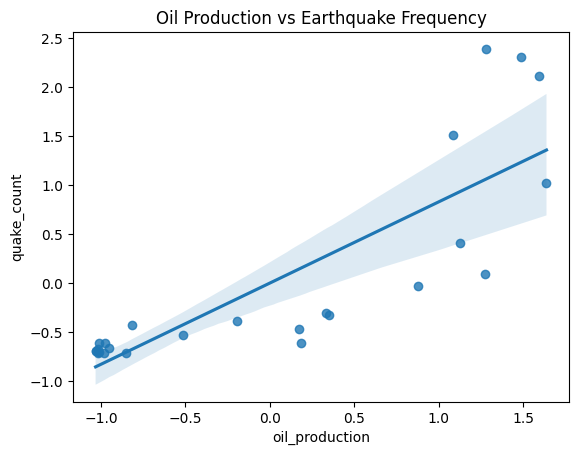

Slope:        0.8285
Intercept:    -0.0000
R-value:      0.8285
R-squared:    0.6863
T-statistic:  7.0941
P-value:      0.0000003161


In [17]:
sns.regplot(
    data=merged_9825,
    x='oil_production',
    y='quake_count'
)

plt.title("Oil Production vs Earthquake Frequency")
plt.show()

result = linregress(
    merged_9825['oil_production'],
    merged_9825['quake_count']
)

t_stat = result.slope / result.stderr

print(f"Slope:        {result.slope:.4f}")
print(f"Intercept:    {result.intercept:.4f}")
print(f"R-value:      {result.rvalue:.4f}")
print(f"R-squared:    {result.rvalue**2:.4f}")
print(f"T-statistic:  {t_stat:.4f}")
print(f"P-value:      {result.pvalue:.10f}")

This model follows the equation: $\widehat{frequency} = 0.8285(oil \ production) + 0$ with and r-squared value of $r^2 = 0.6863$. This tells us that oil production and earthquake frequency follow a **moderate**, **positive** correlation, but we can confirm its significance.

The **Linear Regression T-Test** produced a test statistic of $t_f = 7.0941$ and a corresponding p-value of $p_f = 3.16 \times 10^-7$. Thus, the p-value being below the $\alpha = 0.01$ gives us reason to reject the null in support of the alternative that there is a **significant relationship between annual Texas petroleum production and earthquake frequency**.

Now for with average earthquake magnitude.

Our null and alternative hypotheses are:
* **H<sub>o</sub>:** oil production and average earthquake magnitude are *independent* ($\beta = 0$)
* **H<sub>a</sub>:** oil production and average earthquake magnitude are *not independent* ($\beta \neq 0$)

Again, our benchmark for statistical significance is **$\alpha = 0.01$**.

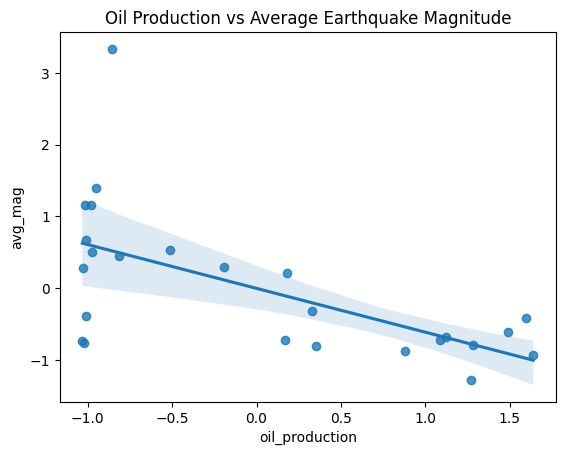

Slope:        -0.6091
Intercept:    -0.0000
R-value:      -0.6091
R-squared:    0.3710
T-statistic:  -3.6834
P-value:      0.0012306631


In [18]:
sns.regplot(
    data=merged_9825,
    x='oil_production',
    y='avg_mag'
)

plt.title("Oil Production vs Average Earthquake Magnitude")
plt.show()

result = linregress(
    merged_9825['oil_production'],
    merged_9825['avg_mag']
)

t_stat = result.slope / result.stderr

print(f"Slope:        {result.slope:.4f}")
print(f"Intercept:    {result.intercept:.4f}")
print(f"R-value:      {result.rvalue:.4f}")
print(f"R-squared:    {result.rvalue**2:.4f}")
print(f"T-statistic:  {t_stat:.4f}")
print(f"P-value:      {result.pvalue:.10f}")

This model follows the equation: $\widehat{average \  magnitude} = -0.6091(oil \ production) + 0$ with and r-squared value of $r^2 = 0.3710$. This tells us that oil production and average earthquake magnitude follow a **weak**, **negative** correlation, but we can confirm its significance.

The **Linear Regression T-Test** produced a test statistic of $t_f = -3.6834$ and a corresponding p-value of $p_f = 1.23 \times 10^-3$. Again, the p-value being below the $\alpha = 0.01$ gives us reason to reject the null in support of the alternative that there is a **significant relationship between annual Texas petroleum production and average earthquake magnitude**.

### **VII. The Gutenberg-Richter Law**

However, this significant negative correlation can be a bit misleading, as it actually has little to do with the consequences of oil extraction itself, but rather a fundamental seismology principle called the **Gutenberg-Richter Law**.

This law states that $log_{10} (N) = a - bM$, where
* $M$ is the earthquake magnitude;
* $N$ is the cumulative number of earthquakes having a magnitude greater than or equal to $M$; and
* $a$ and $b$ are constants depending on the phenomenon, time, and place.

Usually, $b=1$ for seismic activity, so rearranging the equation gives us $N = 10^a \cdot 10^{-M}$.

Therefore, the observed correlation between oil production and average magnitude may simply reflect the underlying relationship between earthquake frequency and magnitude established by the Gutenburg-Richter Law.

As we can see, correlation does not always equal causation.

### **VIII. Conclusion**

In this analysis, we investigated the relationship between Texas petroleum production and seismic activity using EDA, chi-square testing, and linear regression.

Our **chi-square tests** found statistically significant associations between historical time period and both earthquake frequency ($\chi^2 >> 0$, $p \approx 0$) and earthquake magnitude ($p < 0.01$), suggesting that the rise of modern hydraulic fracturing after 1998 coincides with a dramatic increase in seismic activity.

Our **linear regression** models reinforced these findings. We observed a strong positive relationship between oil production and earthquake frequency ($r^2 \approx 0.6863$, $p \approx 3.16 \times 10^{-7}$) and a significant but weaker negative relationship with average earthquake magnitude ($r^2 \approx 0.3710$, $p \approx 1.23 \times 10^{-3}$). The latter, however, is better explained by the **Gutenberg-Richter Law**: as petroleum-induced seismicity increases the total number of earthquakes, the average magnitude naturally decreases, since smaller quakes are exponentially more common.

Taken together, the evidence supports the conclusion that **petroleum extraction is associated with increased earthquake frequency in Texas**, consistent with the broader scientific literature on induced seismicity. However, a few caveats apply: our analysis is correlational, not causal; the earthquake dataset has sparse coverage prior to 1981, which limits some comparisons; and confounding factors such as population growth and improved seismic monitoring may partly explain the rise in recorded events.

Future work could incorporate wastewater injection volumes (a more direct proxy for induced seismicity than production volume), geographic clustering analysis, or depth data to further strengthen these findings.